# ipynb/plant_fewshot_lines.ipynb - Plant 少样本折线图 / Plant few-shot lines

## 项目背景 / Background
Plant 少样本折线图
Plant few-shot lines

## 功能模块 / Modules
- Plant 少样本随 K 变化的折线图
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: fewshot_plant_3way_independent.py、utils/few_shot.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



# Few-Shot Transfer Performance Line Charts

This notebook creates publication-style multi-line charts for few-shot transfer performance
across three RNA modification types: **m5C**, **m6A**, and **Ψ (pseudouridine)**.

**Requirements**:
- R kernel must use the `learn-new` conda environment
- All output files are saved to `plant_png/` subdirectory

**Output files (9 plots + 3 legend files):**
- `plant_png/m5C_fewshot_line.{svg,pdf,png}`
- `plant_png/m6A_fewshot_line.{svg,pdf,png}`
- `plant_png/Psi_fewshot_line.{svg,pdf,png}`
- `plant_png/fewshot_common_legend.{svg,pdf,png}`

In [7]:
# ============================================================
# Cell 1: Load packages and register Times New Roman font
# ============================================================

library(ggplot2)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(ggrepel)
library(grid)
library(gridExtra)

# Register Times New Roman font via showtext
tryCatch({
  font_add("Times New Roman",
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
           bold    = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
  showtext_opts(dpi = 300)
}, error = function(e) {
  message("Times New Roman not found, using system serif fallback.")
  showtext_auto()
})

cat("Packages loaded. Times New Roman registered.\n")

Packages loaded. Times New Roman registered.


In [8]:
# ============================================================
# Cell 2: Read CSV files and reshape to long format
# ============================================================

# Read raw CSV data
m5c_raw <- read.csv("plant_data/m5c.csv")
m6a_raw <- read.csv("plant_data/m6a.csv")
psi_raw <- read.csv("plant_data/y.csv")

# Helper: reshape a raw dataframe to long format for ggplot2
reshape_to_long <- function(df) {
  df <- df %>%
    mutate(
      Shot = factor(Shot, levels = c(0, 2, 10, 20),
                    labels = c("0-shot", "2-shot", "10-shot", "20-shot"))
    ) %>%
    select(Shot, AUC, AUPRC, F1, Rec) %>%
    rename(Recall = Rec) %>%
    pivot_longer(
      cols = c(AUC, AUPRC, F1, Recall),
      names_to = "Metric",
      values_to = "Performance"
    ) %>%
    mutate(
      Metric = factor(Metric, levels = c("AUC", "AUPRC", "F1", "Recall"))
    )
  return(df)
}

# Create long-format data frames
m5c <- reshape_to_long(m5c_raw)
m6a <- reshape_to_long(m6a_raw)
psi <- reshape_to_long(psi_raw)

cat("Data loaded. Rows per dataset:", nrow(m5c), "\n")
cat("\n--- m5C ---\n")
print(m5c, n = 16)
cat("\n--- m6A ---\n")
print(m6a, n = 16)
cat("\n--- Psi ---\n")
print(psi, n = 16)

Data loaded. Rows per dataset: 16 

--- m5C ---
# A tibble: 16 × 3
   Shot    Metric Performance
   <fct>   <fct>        <dbl>
 1 0-shot  AUC          0.719
 2 0-shot  AUPRC        0.379
 3 0-shot  F1           0.396
 4 0-shot  Recall       0.522
 5 2-shot  AUC          0.706
 6 2-shot  AUPRC        0.400
 7 2-shot  F1           0.214
 8 2-shot  Recall       0.564
 9 10-shot AUC          0.714
10 10-shot AUPRC        0.435
11 10-shot F1           0.141
12 10-shot Recall       0.762
13 20-shot AUC          0.866
14 20-shot AUPRC        0.541
15 20-shot F1           0.302
16 20-shot Recall       0.774

--- m6A ---
# A tibble: 16 × 3
   Shot    Metric Performance
   <fct>   <fct>        <dbl>
 1 0-shot  AUC          0.784
 2 0-shot  AUPRC        0.944
 3 0-shot  F1           0.701
 4 0-shot  Recall       0.562
 5 2-shot  AUC          0.789
 6 2-shot  AUPRC        0.942
 7 2-shot  F1           0.795
 8 2-shot  Recall       0.698
 9 10-shot AUC          0.792
10 10-shot AUPRC        0.945
1

In [9]:
# ============================================================
# Cell 3: Common visual parameters, theme, and plot function
# ============================================================

# ---- Morandi color palette (low saturation, publication-quality) ----
morandi_colors <- c(
  "AUC"    = "#7D9CB5",   # dusty muted blue
  "AUPRC"  = "#9CB096",   # sage muted green
  "F1"     = "#C4916B",   # warm terracotta
  "Recall" = "#A28FB5"    # dusty purple
)

# ---- Shape mappings ----
metric_shapes <- c(
  "AUC"    = 16,   # circle
  "AUPRC"  = 15,   # square
  "F1"     = 17,   # triangle
  "Recall" = 18    # diamond
)

# ---- Linetype mappings ----
metric_lines <- c(
  "AUC"    = "solid",
  "AUPRC"  = "solid",
  "F1"     = "solid",
  "Recall" = "dashed"
)

# ---- Common ggplot2 theme (publication-style) ----
theme_publication <- theme_classic(base_size = 18, base_family = "Times New Roman") +
  theme(
    text              = element_text(family = "Times New Roman", size = 18),
    axis.text         = element_text(size = 18, color = "black"),
    axis.title        = element_text(size = 18),
    plot.title        = element_text(size = 18, hjust = 0.5, face = "plain"),
    legend.text       = element_text(size = 18),
    legend.title      = element_blank(),
    legend.position   = "bottom",
    legend.key.width  = unit(1.2, "cm"),
    legend.key.height = unit(0.4, "cm"),
    legend.margin     = margin(4, 4, 4, 4),
    # Grid lines: horizontal only, light grey
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.3),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    # White background
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    # Axis lines: clean and thin
    axis.line  = element_line(color = "black", linewidth = 0.5),
    axis.ticks = element_line(color = "black", linewidth = 0.5),
    # Plot margin: extra space so 18 pt text is not crowded
    plot.margin = margin(12, 18, 12, 18)
  )

# ---- Plotting function ----
# Creates a consistent line chart for a given dataset
create_plot <- function(df, title_text, annot_df) {
  p <- ggplot(df, aes(x = Shot, y = Performance,
                      color = Metric, shape = Metric,
                      linetype = Metric, group = Metric)) +
    # Lines
    geom_line(linewidth = 1.0) +
    # Data point markers
    geom_point(size = 3.0, stroke = 0.5) +
    # Annotate only 0-shot and 20-shot values (avoid chart clutter)
    geom_text_repel(
      data          = annot_df,
      aes(label     = sprintf("%.2f", Performance)),
      size          = 18 / .pt,
      family        = "Times New Roman",
      force         = 3,
      max.overlaps  = Inf,
      direction     = "y",
      segment.size  = 0.2,
      min.segment.length = 0,
      show.legend   = FALSE,
      box.padding   = 0.3,
      point.padding = 0.3
    ) +
    # Color, shape, linetype scales
    scale_color_manual(values = morandi_colors) +
    scale_shape_manual(values = metric_shapes) +
    scale_linetype_manual(values = metric_lines) +
    # Y-axis: exactly 0–1 range for cross-chart comparison
    scale_y_continuous(expand = c(0, 0)) +
    coord_cartesian(ylim = c(0, 1), clip = "off") +
    # Labels
    labs(
      title = title_text,
      x     = "Shot setting",
      y     = "Performance"
    ) +
    theme_publication

  return(p)
}

# ---- Output directory ----
out_dir <- "plant_png"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# ---- Output saving helper ----
save_plots <- function(p, basename) {
  # PDF
  pdf(file.path(out_dir, paste0(basename, ".pdf")), width = 4.5, height = 3.6)
  print(p)
  dev.off()

  # SVG via Cairo
  Cairo::CairoSVG(file.path(out_dir, paste0(basename, ".svg")), width = 4.5, height = 3.6)
  print(p)
  dev.off()

  # PNG 600 dpi
  Cairo::CairoPNG(file.path(out_dir, paste0(basename, ".png")), width = 4.5, height = 3.6,
                  units = "in", dpi = 600, bg = "white")
  print(p)
  dev.off()

  cat("Saved:", file.path(out_dir, basename), ".{pdf,svg,png}\n")
}

cat("Common parameters, theme, and helper functions defined.\n")

Common parameters, theme, and helper functions defined.


Saved: plant_png/m5C_fewshot_line .{pdf,svg,png}


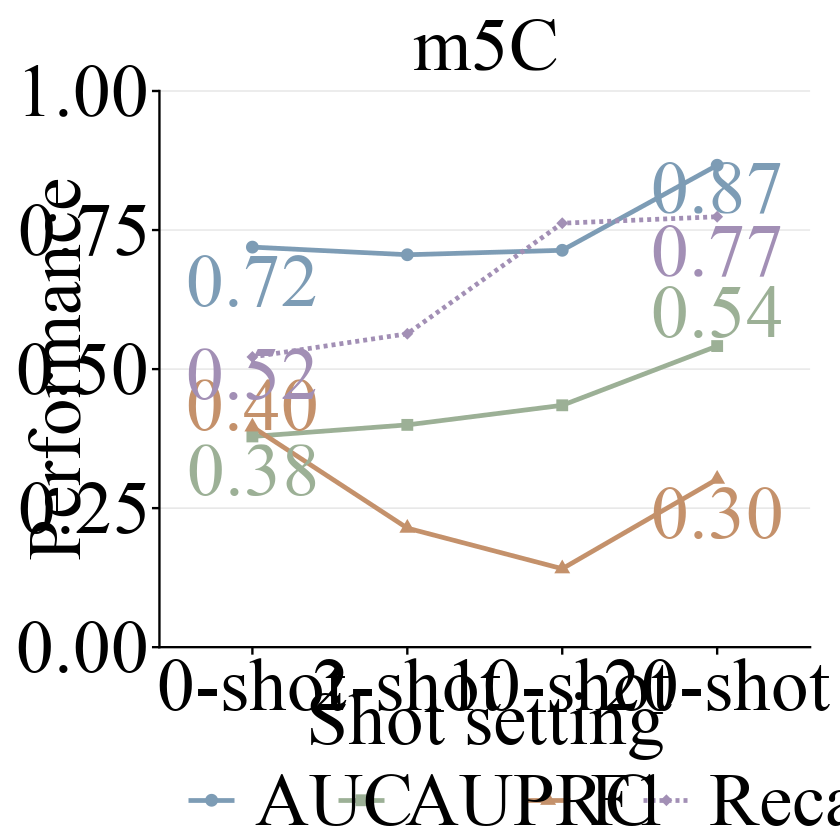

In [10]:
# ============================================================
# Cell 4: Plot m5C
# ============================================================

# Prepare annotation data (0-shot and 20-shot only)
annot_m5c <- m5c %>% filter(Shot %in% c("0-shot", "20-shot"))

# Create plot
p_m5c <- create_plot(m5c, "m5C", annot_m5c)

# Display inline
print(p_m5c)

# Save to files
save_plots(p_m5c, "m5C_fewshot_line")

Saved: plant_png/m6A_fewshot_line .{pdf,svg,png}


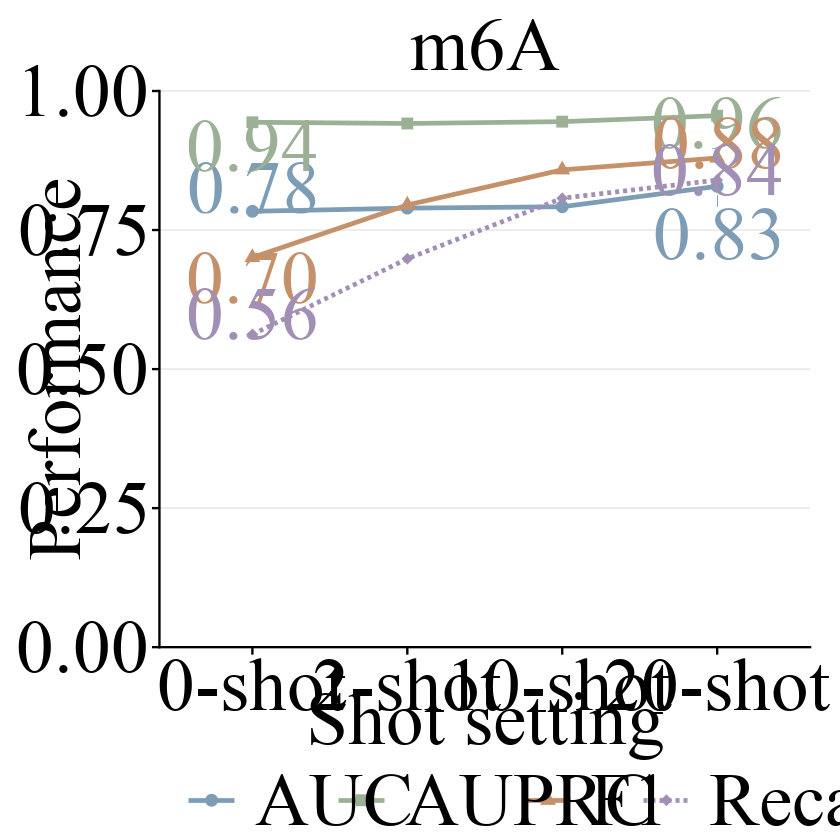

In [11]:
# ============================================================
# Cell 5: Plot m6A
# ============================================================

# Prepare annotation data (0-shot and 20-shot only)
annot_m6a <- m6a %>% filter(Shot %in% c("0-shot", "20-shot"))

# Create plot
p_m6a <- create_plot(m6a, "m6A", annot_m6a)

# Display inline
print(p_m6a)

# Save to files
save_plots(p_m6a, "m6A_fewshot_line")

Saved: plant_png/Psi_fewshot_line .{pdf,svg,png}


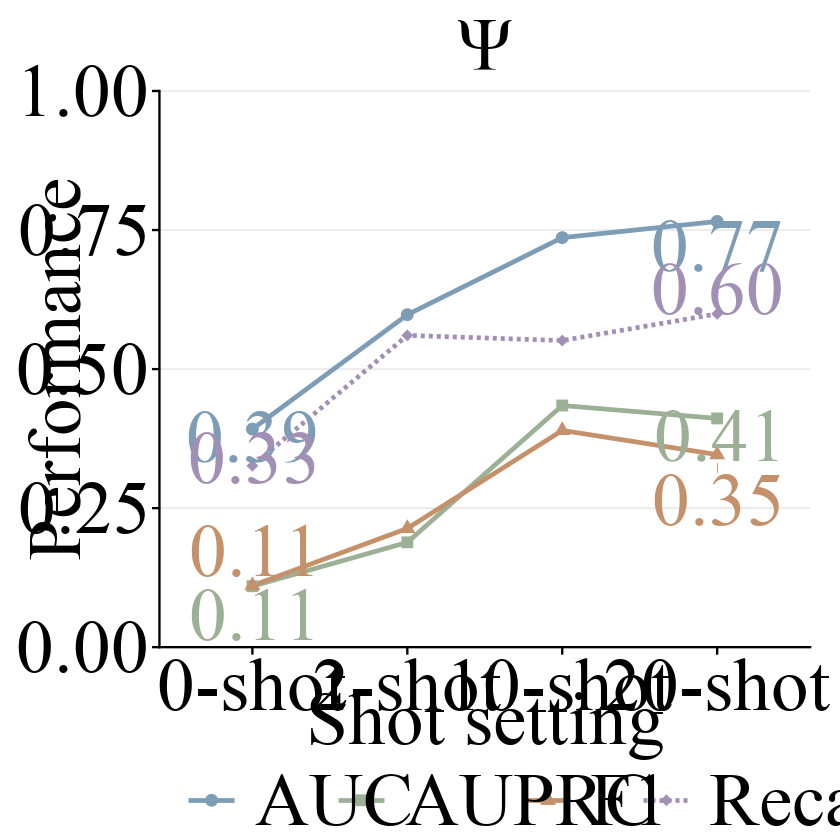

In [12]:
# ============================================================
# Cell 6: Plot Psi (pseudouridine)
# ============================================================

# Prepare annotation data (0-shot and 20-shot only)
annot_psi <- psi %>% filter(Shot %in% c("0-shot", "20-shot"))

# Create plot (title uses Greek capital letter Psi)
p_psi <- create_plot(psi, "Ψ", annot_psi)

# Display inline
print(p_psi)

# Save to files
save_plots(p_psi, "Psi_fewshot_line")

In [13]:
# ============================================================
# Cell 7: Extract and save common legend
# ============================================================

# Extract the legend grob from one of the full plots (m5C)
# This ensures the legend is identical to what appears on the charts
g <- ggplotGrob(p_m5c)
legend_idx <- which(sapply(g$grobs, function(x) x$name) == "guide-box")

if (length(legend_idx) == 0) {
  stop("Could not find legend grob in the plot.")
}

legend_grob <- g$grobs[[legend_idx]]

# Function to save the legend standalone
save_legend <- function(lgrob, basename) {
  # PDF -- wide landscape to fit horizontal legend comfortably
  pdf(file.path(out_dir, paste0(basename, ".pdf")), width = 8, height = 1.5)
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  # SVG via Cairo
  Cairo::CairoSVG(file.path(out_dir, paste0(basename, ".svg")), width = 8, height = 1.5)
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  # PNG 600 dpi
  Cairo::CairoPNG(file.path(out_dir, paste0(basename, ".png")), width = 8, height = 1.5,
                  units = "in", dpi = 600, bg = "white")
  grid::grid.newpage()
  grid::grid.draw(lgrob)
  dev.off()

  cat("Saved legend:", file.path(out_dir, basename), ".{pdf,svg,png}\n")
}

save_legend(legend_grob, "fewshot_common_legend")

cat("\n=== All done! ===\n")
cat("Generated 12 files:\n")
cat("  Plots: m5C_fewshot_line.{pdf,svg,png}\n")
cat("  Plots: m6A_fewshot_line.{pdf,svg,png}\n")
cat("  Plots: Psi_fewshot_line.{pdf,svg,png}\n")
cat("  Legend: fewshot_common_legend.{pdf,svg,png}\n")

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Times New Roman' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font 

Saved legend: plant_png/fewshot_common_legend .{pdf,svg,png}

=== All done! ===
Generated 12 files:
  Plots: m5C_fewshot_line.{pdf,svg,png}
  Plots: m6A_fewshot_line.{pdf,svg,png}
  Plots: Psi_fewshot_line.{pdf,svg,png}
  Legend: fewshot_common_legend.{pdf,svg,png}
